#  SQL Анализ E-Commerce продаж 2024

**Датасет:** E-Commerce Sales Data 2024 (Kaggle) — 3,900 покупателей  
**Инструменты:** Python, SQLite, pandas, matplotlib  
**Цель:** найти продуктовые инсайты через SQL запросы

---

### План работы
1. Загрузка данных в SQLite
2. Базовые метрики
3. Анализ по категориям и товарам
4. Сегментация покупателей
5. Window Functions и CTE
6. Визуализация
7. Выводы

## 1. Загрузка данных

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

customers = pd.read_csv('customer_details.csv')
customers.columns = [c.replace(' ', '_').replace('(', '').replace(')', '') for c in customers.columns]

conn = sqlite3.connect(':memory:')
customers.to_sql('customers', conn, index=False, if_exists='replace')

def query(sql):
    return pd.read_sql(sql, conn)

query("SELECT * FROM customers LIMIT 3")

## 2. Базовые метрики

In [ ]:
display(query("""
    SELECT 
        COUNT(*) as total_customers,
        ROUND(AVG(Purchase_Amount_USD), 2) as avg_purchase,
        ROUND(AVG(Age), 1) as avg_age,
        MIN(Purchase_Amount_USD) as min_purchase,
        MAX(Purchase_Amount_USD) as max_purchase
    FROM customers
"""))

## 3. Анализ по категориям и товарам


In [ ]:
display(query("""
    SELECT 
        Category,
        COUNT(*) as orders_count,
        SUM(Purchase_Amount_USD) as total_revenue,
        ROUND(AVG(Purchase_Amount_USD), 2) as avg_order
    FROM customers
    GROUP BY Category
    ORDER BY total_revenue DESC
"""))

display(query("""
    SELECT 
        Item_Purchased,
        COUNT(*) as orders_count,
        SUM(Purchase_Amount_USD) as total_revenue
    FROM customers
    GROUP BY Item_Purchased
    ORDER BY total_revenue DESC
    LIMIT 10
"""))

,total_customers,avg_purchase,avg_age,min_purchase,max_purchase
0,3900,59.76,44.1,20,100


,Category,orders_count,total_revenue,avg_order
0,Clothing,1737,104264,60.03
1,Accessories,1240,74200,59.84
2,Footwear,599,36093,60.26
3,Outerwear,324,18524,57.17


,Item_Purchased,orders_count,total_revenue
0,Blouse,171,10410
1,Shirt,169,10332
2,Dress,166,10320
3,Pants,171,10090
4,Jewelry,171,10010
5,Sunglasses,161,9649
6,Belt,161,9635
7,Scarf,157,9561
8,Sweater,164,9462
9,Shorts,157,9433


## 4. Сегментация покупателей

In [ ]:
display(query("""
    SELECT 
        Gender,
        COUNT(*) as customers,
        ROUND(AVG(Purchase_Amount_USD), 2) as avg_purchase,
        SUM(Purchase_Amount_USD) as total_revenue
    FROM customers
    GROUP BY Gender
    ORDER BY total_revenue DESC
"""))

display(query("""
    SELECT 
        Subscription_Status,
        COUNT(*) as customers,
        ROUND(AVG(Purchase_Amount_USD), 2) as avg_purchase,
        ROUND(AVG(Review_Rating), 2) as avg_rating,
        ROUND(AVG(Previous_Purchases), 1) as avg_previous_purchases
    FROM customers
    GROUP BY Subscription_Status
"""))

display(query("""
    SELECT
        Payment_Method,
        COUNT(*) as orders,
        ROUND(AVG(Purchase_Amount_USD), 2) as avg_order,
        SUM(Purchase_Amount_USD) as total_revenue
    FROM customers
    GROUP BY Payment_Method
    ORDER BY total_revenue DESC
"""))

,Gender,customers,avg_purchase,total_revenue
0,Male,2652,59.54,157890
1,Female,1248,60.25,75191


,Season,Category,orders,revenue
0,Fall,Clothing,427,26220
1,Fall,Accessories,324,19874
2,Fall,Footwear,136,8665
3,Fall,Outerwear,88,5259
4,Spring,Clothing,454,27692
5,Spring,Accessories,301,17007
6,Spring,Footwear,163,9555
7,Spring,Outerwear,81,4425
8,Summer,Clothing,408,23078
9,Summer,Accessories,312,19028


,Subscription_Status,customers,avg_purchase,avg_rating,avg_previous_purchases
0,No,2847,59.87,3.75,25.1
1,Yes,1053,59.49,3.74,26.1


,Payment_Method,orders,avg_order,total_revenue
0,Credit Card,671,60.07,40310
1,PayPal,677,59.25,40109
2,Cash,670,59.70,40002
3,Debit Card,636,60.92,38742
4,Venmo,634,58.95,37374
5,Bank Transfer,612,59.71,36544


## 5. Window Functions и CTE

In [ ]:
display(query("""
    WITH customer_segments AS (
        SELECT 
            Customer_ID,
            Purchase_Amount_USD,
            Previous_Purchases,
            CASE 
                WHEN Previous_Purchases >= 25 THEN 'Лояльный'
                WHEN Previous_Purchases >= 10 THEN 'Активный'
                ELSE 'Новый'
            END as segment
        FROM customers
    )
    SELECT 
        segment,
        COUNT(*) as customers,
        ROUND(AVG(Purchase_Amount_USD), 2) as avg_purchase,
        SUM(Purchase_Amount_USD) as total_revenue
    FROM customer_segments
    GROUP BY segment
    ORDER BY total_revenue DESC
"""))

display(query("""
    WITH category_stats AS (
        SELECT 
            Category,
            Item_Purchased,
            SUM(Purchase_Amount_USD) as revenue,
            COUNT(*) as orders
        FROM customers
        GROUP BY Category, Item_Purchased
    ),
    ranked AS (
        SELECT *,
            RANK() OVER (PARTITION BY Category ORDER BY revenue DESC) as rank
        FROM category_stats
    )
    SELECT Category, Item_Purchased, revenue, orders, rank
    FROM ranked
    WHERE rank <= 3
    ORDER BY Category, rank
"""))

display(query("""
    SELECT
        CASE
            WHEN Age BETWEEN 18 AND 25 THEN '18-25'
            WHEN Age BETWEEN 26 AND 35 THEN '26-35'
            WHEN Age BETWEEN 36 AND 50 THEN '36-50'
            ELSE '50+'
        END as age_group,
        COUNT(*) as customers,
        ROUND(AVG(Purchase_Amount_USD), 2) as avg_purchase,
        ROUND(AVG(Review_Rating), 2) as avg_rating
    FROM customers
    GROUP BY age_group
    ORDER BY avg_purchase DESC
"""))

,segment,customers,avg_purchase,total_revenue
0,Лояльный,2014,59.98,120803
1,Активный,1178,58.69,69136
2,Новый,708,60.94,43142


,Category,Item_Purchased,revenue,orders,rank
0,Accessories,Jewelry,10010,171,1
1,Accessories,Sunglasses,9649,161,2
2,Accessories,Belt,9635,161,3
3,Clothing,Blouse,10410,171,1
4,Clothing,Shirt,10332,169,2
5,Clothing,Dress,10320,166,3
6,Footwear,Shoes,9240,150,1
7,Footwear,Sandals,9200,160,2
8,Footwear,Boots,9018,144,3
9,Outerwear,Coat,9275,161,1


,Age,age_group,customers,avg_purchase,avg_rating
0,19,18-25,571,60.65,3.82
1,55,50+,1476,59.95,3.73
2,27,26-35,742,59.76,3.74
3,50,36-50,1111,59.07,3.75


## 6. Визуализация

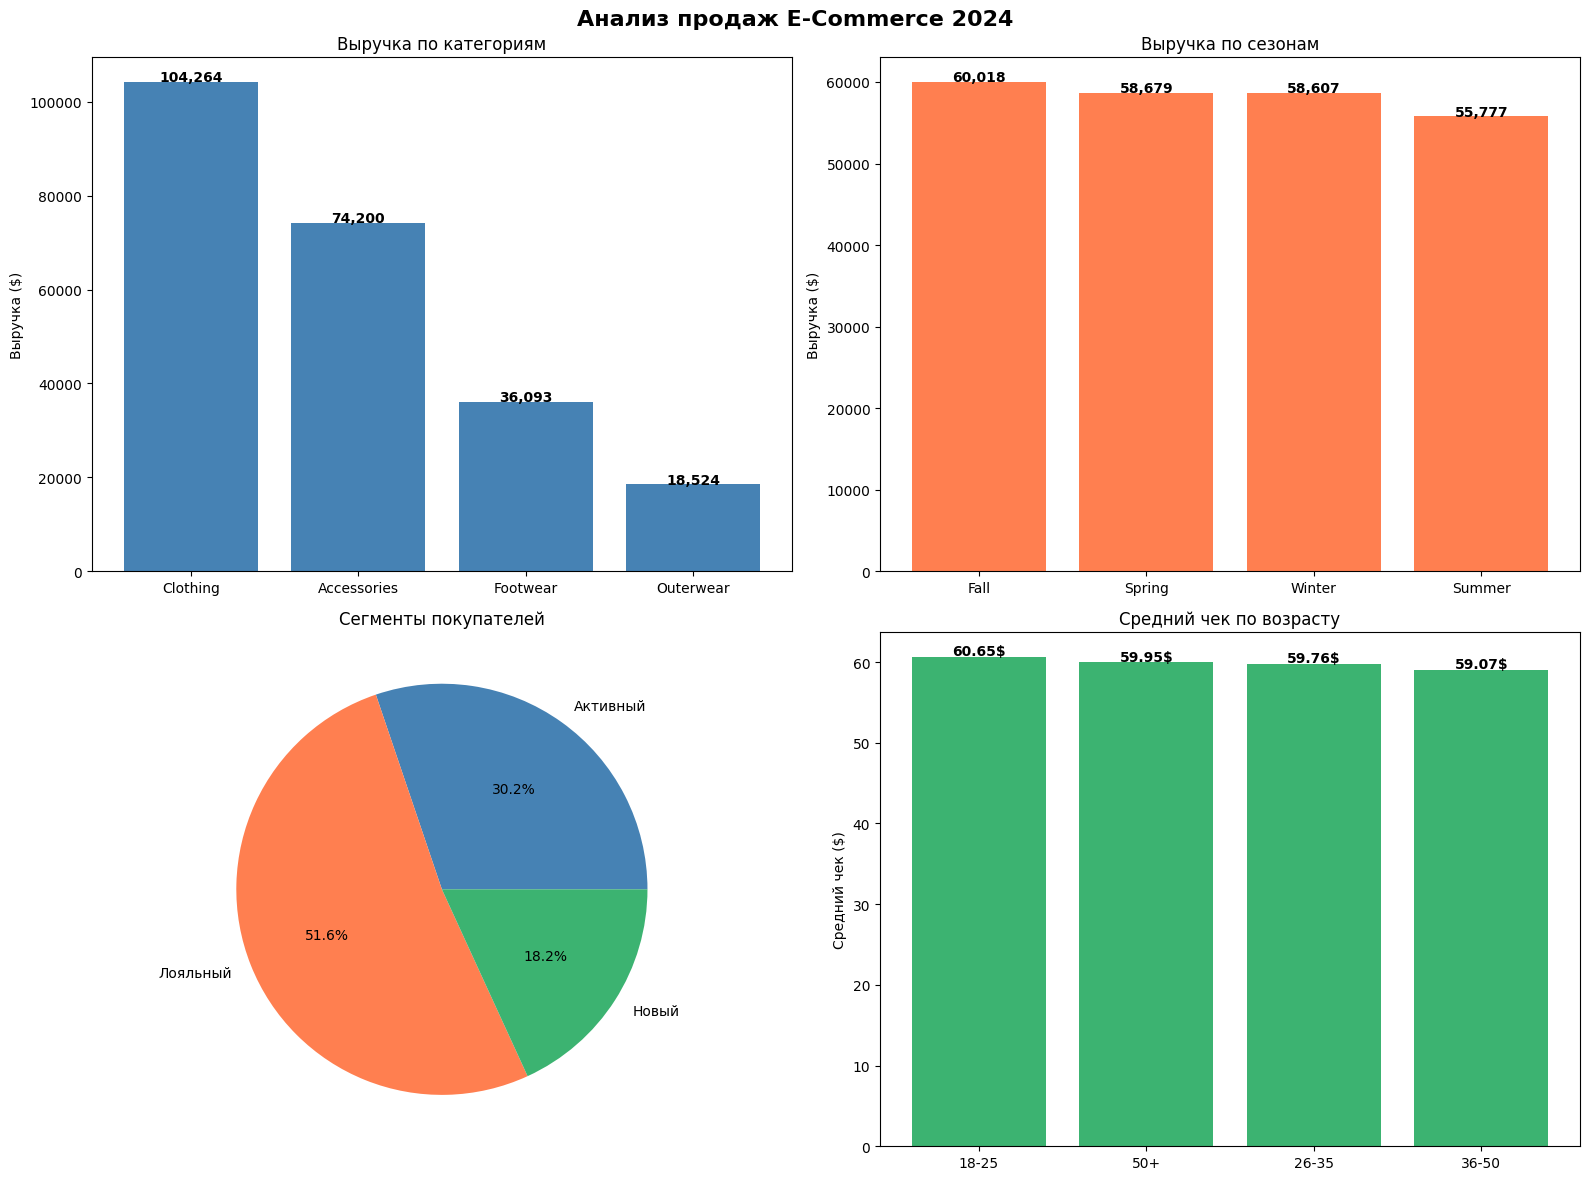

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Анализ продаж E-Commerce 2024', fontsize=16, fontweight='bold')

category_data = query("""
    SELECT Category, SUM(Purchase_Amount_USD) as revenue
    FROM customers GROUP BY Category ORDER BY revenue DESC
""")
axes[0, 0].bar(category_data['Category'], category_data['revenue'], color='steelblue')
axes[0, 0].set_title('Выручка по категориям')
axes[0, 0].set_ylabel('Выручка ($)')
for i, v in enumerate(category_data['revenue']):
    axes[0, 0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

season_data = query("""
    SELECT Season, SUM(Purchase_Amount_USD) as revenue
    FROM customers GROUP BY Season ORDER BY revenue DESC
""")
axes[0, 1].bar(season_data['Season'], season_data['revenue'], color='coral')
axes[0, 1].set_title('Выручка по сезонам')
axes[0, 1].set_ylabel('Выручка ($)')
for i, v in enumerate(season_data['revenue']):
    axes[0, 1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

segment_data = query("""
    WITH s AS (
        SELECT CASE 
            WHEN Previous_Purchases >= 25 THEN 'Лояльный'
            WHEN Previous_Purchases >= 10 THEN 'Активный'
            ELSE 'Новый'
        END as segment, COUNT(*) as cnt
        FROM customers GROUP BY segment
    )
    SELECT * FROM s
""")
axes[1, 0].pie(segment_data['cnt'], labels=segment_data['segment'],
               autopct='%1.1f%%', colors=['steelblue', 'coral', 'mediumseagreen'])
axes[1, 0].set_title('Сегменты покупателей')

age_data = query("""
    SELECT CASE
        WHEN Age BETWEEN 18 AND 25 THEN '18-25'
        WHEN Age BETWEEN 26 AND 35 THEN '26-35'
        WHEN Age BETWEEN 36 AND 50 THEN '36-50'
        ELSE '50+'
    END as age_group,
    ROUND(AVG(Purchase_Amount_USD), 2) as avg_purchase
    FROM customers GROUP BY age_group ORDER BY avg_purchase DESC
""")
axes[1, 1].bar(age_data['age_group'], age_data['avg_purchase'], color='mediumseagreen')
axes[1, 1].set_title('Средний чек по возрасту')
axes[1, 1].set_ylabel('Средний чек ($)')
for i, v in enumerate(age_data['avg_purchase']):
    axes[1, 1].text(i, v + 0.2, f'{v}$', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Выводы

### Ключевые инсайты

**1. Clothing — главная категория (выручка 104,264$)**
Вдвое больше чем Accessories и втрое больше Outerwear.

**2. Сезонность минимальная**
Все сезоны дают 55-60k$ выручки — бизнес стабилен круглый год.

**3. 51.6% покупателей — лояльные (25+ покупок)**
Больше половины базы — постоянные клиенты. Высокий retention.

**4. Возраст не влияет на средний чек**
Все возрастные группы тратят ~59-60$ — универсальный продукт.

**5. Способы оплаты распределены равномерно**
Credit Card, PayPal, Cash — каждый ~400$ выручки. Нет доминирующего метода.

**6. Подписка не увеличивает средний чек**
Подписчики: 59.49$ vs неподписчики: 59.87$ — разница незначительная.